Datasets Link: https://www.kaggle.com/datasets/meirnizri/covid19-dataset

**content**

The dataset was provided by the Mexican government (link). This dataset contains an enormous number of anonymized patient-related information including pre-conditions. The raw dataset consists of 21 unique features and 1,048,576 unique patients. In the Boolean features, 1 means "yes" and 2 means "no". values as 97 and 99 are missing data.

- sex: 1 for female and 2 for male.
- age: of the patient.
- classification: covid test findings. Values 1-3 mean that the patient was diagnosed with covid in different degrees. 4 or higher means that the patient is not a carrier of covid or that the test is inconclusive.
- patient type: type of care the patient received in the unit. 1 for returned home and 2 for hospitalization.
- pneumonia: whether the patient already have air sacs inflammation or not.
- pregnancy: whether the patient is pregnant or not.
- diabetes: whether the patient has diabetes or not.
- copd: Indicates whether the patient has Chronic obstructive pulmonary disease or not.
- asthma: whether the patient has asthma or not.
- inmsupr: whether the patient is immunosuppressed or not.
- hypertension: whether the patient has hypertension or not.
- cardiovascular: whether the patient has heart or blood vessels related disease.
- renal chronic: whether the patient has chronic renal disease or not.
- other disease: whether the patient has other disease or not.
- obesity: whether the patient is obese or not.
- tobacco: whether the patient is a tobacco user.
- usmr: Indicates whether the patient treated medical units of the first, second or third level.
- medical unit: type of institution of the National Health System that provided the care.
- intubed: whether the patient was connected to the ventilator.
- icu: Indicates whether the patient had been admitted to an Intensive Care Unit.
- date died: If the patient died indicate the date of death, and 9999-99-99 otherwise.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download('meirnizri/covid19-dataset')
df = pd.read_csv(os.path.join(path, 'Covid Data.csv'))
df.head()

Using Colab cache for faster access to the 'covid19-dataset' dataset.


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [ ]:
# Info About Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [ ]:
# Describe About Data
df.describe()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [ ]:
# Checking The Empty Data
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Duplicate data here are people who have the same condition but are not necessarily alive
# Just Keep As Is
df.duplicated().sum()

np.int64(812049)

In [ ]:
# Seeing Unique Value In Each Columns In Data
columns = df.columns.to_list()
exception_column = ['AGE', 'DATE_DIED']

for column in columns:
    # And Then Change Value 97, 98, 99 Because Are Missing Data
    if column not in exception_column:
        df[column] = df[column].replace([97, 98, 99], 3)
        print(f"\n- {column}\n", df[column].unique(), "\n")


- USMER
 [2 1] 


- MEDICAL_UNIT
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13] 


- SEX
 [1 2] 


- PATIENT_TYPE
 [1 2] 


- INTUBED
 [3 1 2] 


- PNEUMONIA
 [1 2 3] 


- PREGNANT
 [2 3 1] 


- DIABETES
 [2 1 3] 


- COPD
 [2 1 3] 


- ASTHMA
 [2 1 3] 


- INMSUPR
 [2 1 3] 


- HIPERTENSION
 [1 2 3] 


- OTHER_DISEASE
 [2 1 3] 


- CARDIOVASCULAR
 [2 1 3] 


- OBESITY
 [2 1 3] 


- RENAL_CHRONIC
 [2 1 3] 


- TOBACCO
 [2 1 3] 


- CLASIFFICATION_FINAL
 [3 5 7 6 1 2 4] 


- ICU
 [3 2 1] 



In [ ]:
# Making New Column For This Patient Still Alive Or Not
# Created an ALIVE column (where 1 = Alive). For death prediction cases, it's easier and standard if we flip the target to DIED (where 1 = Died and 0 = Alive). That way, the minority class (patients who died) is labeled 1, so the balancing parameter (scale_pos_weight) can work optimally to achieve high Recall.
df['DIED'] = [0 if i == '9999-99-99' else 1 for i in df['DATE_DIED']]
df['DIED'].head()

,DIED
0,1
1,1
2,1
3,1
4,1


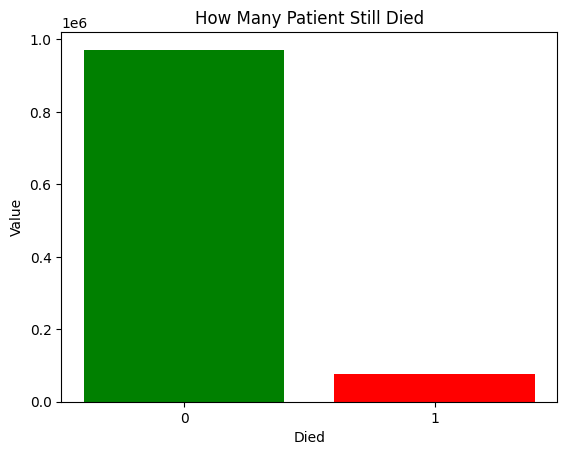

In [ ]:
# Seeing The Died Value With Diagram
target = df['DIED'].value_counts()
plt.bar(target.index.astype(str), target.values, color=['green', 'red'])
plt.xlabel('Died')
plt.ylabel('Value')
plt.title('How Many Patient Still Died')
plt.show()

In [ ]:
# Split The Data Into X, y
X = df.drop(['DIED', 'DATE_DIED'], axis=1)
y = df['DIED']

In [ ]:
# Split Data with Stratified (It is important that the proportion of deaths is the same in train & test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Automatically calculate scale_pos_weight to address imbalanced data
# Formula: Number of living patients (0) / Number of deceased patients (1)
number_alive = (y_train == 0).sum()
number_dead = (y_train == 1).sum()
scale_weight = number_alive / number_dead

print(f"Number of Living Patients (0): {number_alive:,}")
print(f"Number of Died Patients (1): {number_dead:,}")
print(f"Penalty Weight (scale_pos_weight): {scale_weight:.2f}\n")

Number of Living Patients (0): 777,306
Number of Died Patients (1): 61,554
Penalty Weight (scale_pos_weight): 12.63



**The Parameter Model That Used For:**
1.  scale_pos_weight = scale_weight
- Function & Why It Exists: This is the ultimate lifesaver for the class imbalance problem we discussed earlier. Since the number of deceased COVID-19 patients (minority class) is much lower than the number of survivors, this parameter provides a mathematical "penalty" or additional weight when the model incorrectly predicts a patient as deceased.
- Purpose: Forces the model to not ignore the minority class and pursue high Recall so that no at-risk patients are missed.
2.  learning_rate = 0.1 (or often called eta)
- Function & Why It Exists: Controls how fast or slow the model learns from each added decision tree.
- Purpose: A value of 0.1 means that each new tree contributes only a small correction (shrinking the learning step). Learning slowly and carefully has been shown to make the model much more accurate and less prone to overfitting than learning aggressively (e.g. learning_rate = 1.0).
3.  max_depth = 6
- Function & Why It Exists: Determines how "deep" each decision tree is allowed to branch. The number 6 means that in one tree, there are a maximum of 6 levels of conditional questions (e.g.: Check Age $\rightarrow$ Check Pneumonia $\rightarrow$ Check Diabetes $\rightarrow$ etc.).
- Purpose: Controlling model complexity. If max_depth is too large (e.g. 20), the model will be too complex and memorize the training data (overfitting). If it is too small (e.g. 2), the model will be too simple (underfitting). The number 6 is a safe gold standard for most cases.
4.  n_estimators = 150
- Function & Why It Exists: Determines the total number of decision trees (boosting rounds) that will be created sequentially.
- Purpose: The number 150 means that XGBoost will build 150 trees, where each new tree is tasked with correcting the errors of the previous tree. The larger the number, the smarter the model can be, but the training process will take longer.  
5. random_state = 42
- Function & Why It Exists: Locks the computer's internal random number (seed). The number "42" is just a common convention in the IT world.
- Purpose: To ensure that random results (such as when slicing data or randomly selecting features) are consistent every time you rerun the code. Without this, each time you run the code, the model's accuracy can fluctuate slightly due to randomness.
6.  n_jobs = -1
- Function & Why It Exists: Controls the use of computer processor (CPU) resources.
- Purpose: The number -1 tells XGBoost to use all available CPU cores on your
computer to the maximum. This makes the process of training 1 million rows of data much faster than using only 1 core.

In [ ]:
# Making The Model
model = xgb.XGBClassifier(
    scale_pos_weight = scale_weight,
    learning_rate = 0.1,
    max_depth = 6,
    n_estimators = 150,
    random_state = 42,
    n_jobs = -1
)

In [ ]:
# Training Model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Testing Model
y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9953    0.8871    0.9381    194327
           1     0.3991    0.9468    0.5615     15388

    accuracy                         0.8915    209715
   macro avg     0.6972    0.9170    0.7498    209715
weighted avg     0.9515    0.8915    0.9104    209715



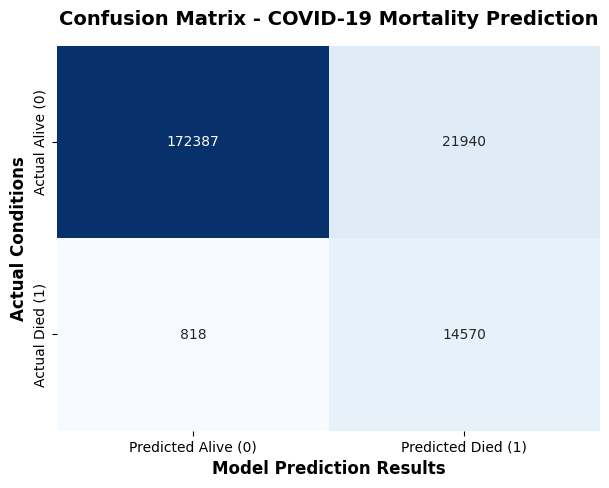

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calculate the confusion matrix from your y_test and y_pred
cm = confusion_matrix(y_test, y_pred)

# 2. Set the figure size
plt.figure(figsize=(7, 5))

# 3. Create a Heatmap using Seaborn
sns.heatmap(
cm,

annot=True, # Display numbers in boxes

fmt='d', # Format numbers as integers (no decimals)

cmap='Blues', # Color theme (blue)

cbar=False, # Remove the color bar on the side (optional)

xticklabels=['Predicted Alive (0)', 'Predicted Died (1)'],

yticklabels=['Actual Alive (0)', 'Actual Died (1)']
)

# 4. Label and Title
plt.xlabel('Model Prediction Results', fontsize=12, fontweight='bold')
plt.ylabel('Actual Conditions', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - COVID-19 Mortality Prediction', fontsize=14, fontweight='bold', pad=15)

# 5. Display the Image
plt.show()

<Figure size 1000x800 with 0 Axes>

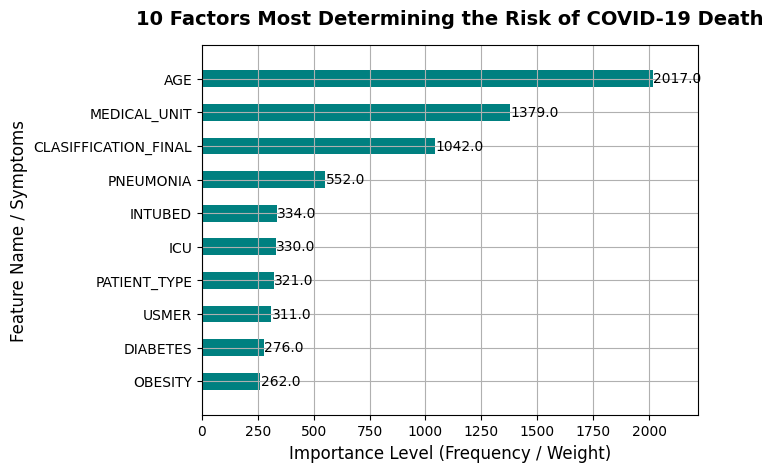

In [ ]:
# 1. Set the figure size
plt.figure(figsize=(10, 8))

# 2. Plot the top 10 most influential features according to XGBoost
xgb.plot_importance(
model,
max_num_features=10, # Displays the top 10 features
height=0.5, # Bar thickness of the chart
color='teal', # Chart color
importance_type='weight' # Based on how frequently the feature is used in the tree branching
)

# 3. Give it a title and aesthetics
plt.title('10 Factors Most Determining the Risk of COVID-19 Death', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Level (Frequency / Weight)', fontsize=12)
plt.ylabel('Feature Name / Symptoms', fontsize=12)

plt.show()